In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sbn


In [9]:
data = pd.read_csv("ER_by_type_2016_2022_USA.csv")
data.head()

,Year,Measure Type,Leading 10 Ranking,Measure,Group,Subgroup,Estimate Type,Estimate,Standard Error,Lower 95% CI,Upper 95% CI,Reliable
0,2016,By primary diagnosis,0,All diagnoses,Total,All visits,Visit count,145591000.0,8798000.0,128347000.0,162835000.0,Yes
1,2016,By primary diagnosis,0,All diagnoses,By sex,Female,Visit count,79595000.0,4803000.0,70182000.0,89008000.0,Yes
2,2016,By primary diagnosis,0,All diagnoses,By sex,Male,Visit count,65996000.0,4119000.0,57923000.0,74070000.0,Yes
3,2016,By primary diagnosis,0,All diagnoses,By age,0-17 years old,Visit count,32146000.0,2840000.0,26579000.0,37713000.0,Yes
4,2016,By primary diagnosis,0,All diagnoses,By age,18-44 years old,Visit count,55978000.0,3436000.0,49243000.0,62713000.0,Yes


In [3]:
test = data[(data["Group"]== "Total")]
test

,Year,Measure Type,Leading 10 Ranking,Measure,Group,Subgroup,Estimate Type,Estimate,Standard Error,Lower 95% CI,Upper 95% CI,Reliable
0,2016,By primary diagnosis,0,All diagnoses,Total,All visits,Visit count,145591000.0,8798000.0,128347000.0,162835000.0,Yes
22,2016,By primary diagnosis,1,"1. Symptoms, signs, and abnormal clinical and ...",Total,All visits,Visit count,34028000.0,2207000.0,29702000.0,38354000.0,Yes
44,2016,By primary diagnosis,2,2. Injury and poisoning,Total,All visits,Visit count,29888000.0,2063000.0,25845000.0,33931000.0,Yes
66,2016,By primary diagnosis,3,3. Diseases of the respiratory system,Total,All visits,Visit count,14918000.0,1232000.0,12503000.0,17333000.0,Yes
88,2016,By primary diagnosis,4,4. Diseases of the musculoskeletal system and ...,Total,All visits,Visit count,10756000.0,762000.0,9262000.0,12249000.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
6666,2022,By reason for visit,6,"6. Headache, pain in head",Total,All visits,"Visit rate (per 1,000 people)",12.5,1.3,10.0,15.1,Yes
6688,2022,By reason for visit,7,"7. Pain, site not referable to a specific body...",Total,All visits,"Visit rate (per 1,000 people)",10.4,1.1,8.2,12.6,Yes
6710,2022,By reason for visit,8,8. Back symptoms,Total,All visits,"Visit rate (per 1,000 people)",9.8,1.3,7.2,12.5,Yes
6732,2022,By reason for visit,9,9. Vomiting,Total,All visits,"Visit rate (per 1,000 people)",9.1,0.9,7.3,10.9,Yes


In [4]:
def constructing_df_by_diagnosis(data):
    years = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
    new_df = pd.DataFrame()
    targets = data["Measure"].unique()  

    for year in years:
        for target in targets:
            subset = data[
                (data["Measure"] == target)
                & (data["Group"] == "Total")
                & (data["Year"] == year)
                & (data["Estimate Type"] == "Visit count")
            ]
            if not subset.empty:
                new_df = pd.concat([new_df, subset[[ "Year", "Measure", "Estimate", "Standard Error"]]])
    
    new_df["Estimate"].round(0)
    new_df["Standard Error"].round(0)

    new_df["Error %"] = (((new_df["Standard Error"] / new_df["Estimate"])*100)).round(1)

    return new_df

data_by_diagnosis = constructing_df_by_diagnosis(data)
# data_by_diagnosis

data_by_diagnosis


,Year,Measure,Estimate,Standard Error,Error %
0,2016,All diagnoses,145591000.0,8798000.0,6.0
22,2016,"1. Symptoms, signs, and abnormal clinical and ...",34028000.0,2207000.0,6.5
44,2016,2. Injury and poisoning,29888000.0,2063000.0,6.9
66,2016,3. Diseases of the respiratory system,14918000.0,1232000.0,8.3
88,2016,4. Diseases of the musculoskeletal system and ...,10756000.0,762000.0,7.1
...,...,...,...,...,...
3278,2022,"6. Headache, pain in head",4122000.0,421000.0,10.2
3300,2022,"7. Pain, site not referable to a specific body...",3418000.0,372000.0,10.9
3322,2022,8. Back symptoms,3229000.0,441000.0,13.7
3344,2022,9. Vomiting,2988000.0,302000.0,10.1


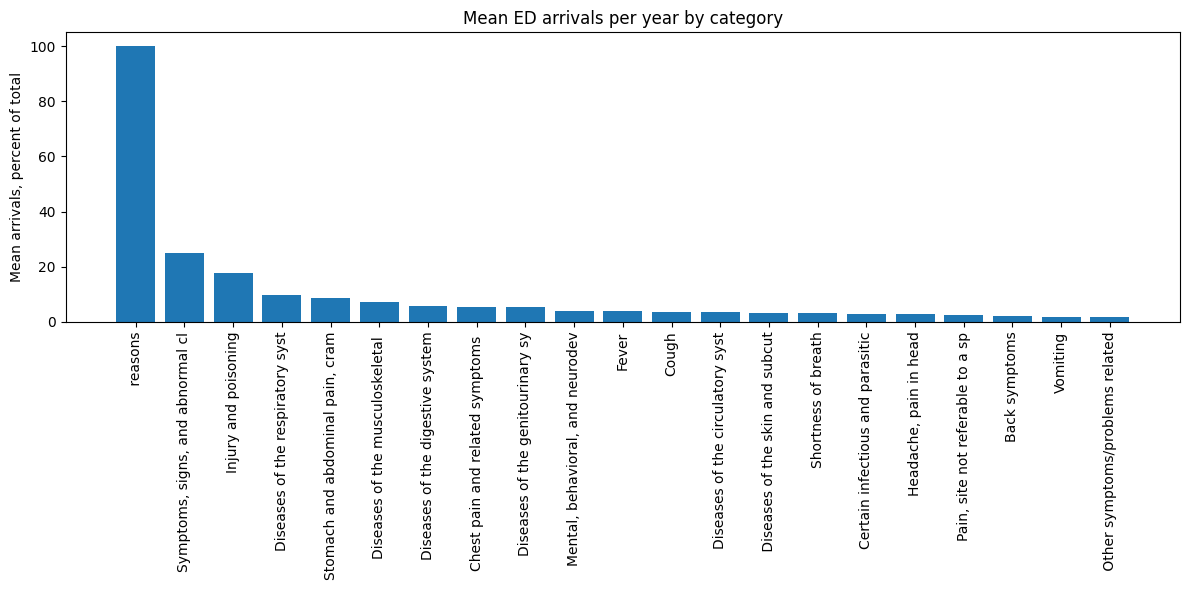

,Measure,Prevalence,Error
0,All reasons,100.000000,6.628571
1,"1. Symptoms, signs, and abnormal clinical and ...",24.903597,7.342857
2,2. Injury and poisoning,17.843371,7.171429
3,3. Diseases of the respiratory system,9.561164,9.328571
4,"1. Stomach and abdominal pain, cramps and spasms",8.620930,7.985714


In [13]:
# unique_diagnoses = data_by_diagnosis["Measure"].unique()

# regrouped_data = pd.DataFrame()
# for diagnose in unique_diagnoses:
#     count = 0
#     for year in data_by_diagnosis["Year"]:
#             if data_by_diagnosis["Year"] == year and data_by_diagnosis["Measure"] == diagnose:
#                 count += data_by_diagnosis["Estimate"]                
#     regrouped_data[diagnose]=count
    

# regrouped_data
            
        

# Keep 2016–2022
df = data_by_diagnosis[data_by_diagnosis["Year"].between(2016, 2022)].copy()

# Drop the aggregate row
types = df[df["Measure"] != "All diagnoses"].copy()

# Sum over years, count years, mean error per type
agg = (
    types.groupby("Measure", as_index=False)
         .agg(Estimate_sum=("Estimate", "sum"),
              N_years=("Year", "nunique"),
              Error=("Error %", "mean"))
)
agg["Mean_per_year"] = agg["Estimate_sum"] / agg["N_years"]

# Denominator for percent of total arrivals
if (df["Measure"] == "All diagnoses").any():
    denom = (
        df[df["Measure"] == "All diagnoses"]
        .groupby("Year")["Estimate"].sum()
        .mean()
    )
else:
    denom = agg["Mean_per_year"].sum()

# Prevalence in percent
agg["Prevalence"] = 100 * agg["Mean_per_year"] / denom

# Sort by prevalence for a clearer plot
agg = agg.sort_values("Prevalence", ascending=False).reset_index(drop=True)

# Plot with vertical labels truncated to 15 characters
labels = [str(s)[3:35] for s in agg["Measure"]]
y = agg["Prevalence"].values

plt.figure(figsize=(12, 6))
plt.bar(range(len(y)), y)
plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Mean arrivals, percent of total")
plt.title("Mean ED arrivals per year by category")
plt.tight_layout()
plt.show()

# Save minimal CSV
out = agg[["Measure", "Prevalence", "Error"]]
out.to_csv("prevalences.csv", index=False)
out.head()


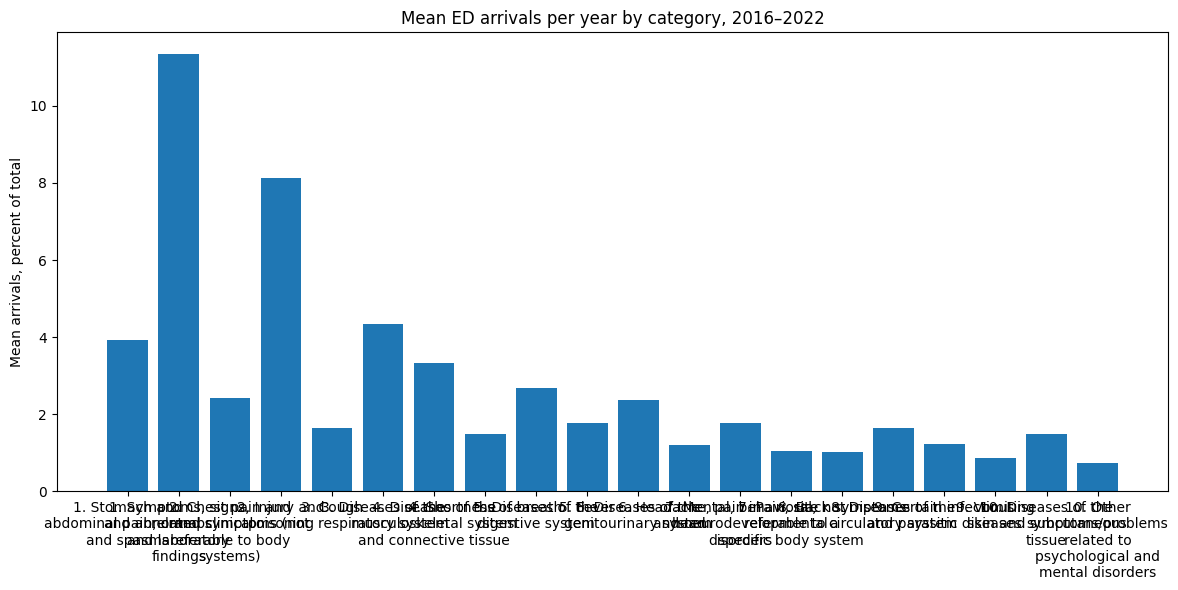

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# Filter and clean
df = data_by_diagnosis.loc[
    data_by_diagnosis["Year"].between(2016, 2022)
].copy()

df = df.dropna(subset=["Estimate"])
df_types = df.loc[df["Measure"] != "All diagnoses"].copy()

# Helper: parse leading number if present, e.g., "3. Diseases of ..."
def leading_num(s):
    try:
        first = s.split(".", 1)[0].strip()
        return int(first)
    except Exception:
        return np.inf  # put unnumbered at end

# Aggregate
grp = df_types.groupby("Measure", as_index=False)
totals = grp["Estimate"].sum().rename(columns={"Estimate": "Total_All_Years"})
nyears = grp["Year"].nunique().rename(columns={"Year": "N_Years"})

by_type = totals.merge(nyears, on="Measure")
by_type["Mean_Per_Year"] = by_type["Total_All_Years"] / by_type["N_Years"]

# Denominator: overall mean arrivals across all Measures
overall_mean = by_type["Mean_Per_Year"].sum()
by_type["Percent_of_Total_Mean"] = 100 * by_type["Mean_Per_Year"] / overall_mean

# Keep top 20 categories if more are present
# and create a sensible order: sort by leading number then name
by_type["LeadNum"] = by_type["Measure"].map(leading_num)
by_type = by_type.sort_values(["LeadNum", "Measure"]).reset_index(drop=True)

# If your dataset has more than 20 categories, trim to 20
if len(by_type) > 20:
    by_type = by_type.head(20)

# Shorten long labels for readability
def wrap_label(s, width=22):
    return "\n".join(textwrap.wrap(s, width))

labels = [wrap_label(m) for m in by_type["Measure"]]
y = by_type["Percent_of_Total_Mean"].values

# Plot: one chart, no custom colors, no seaborn
plt.figure(figsize=(12, 6))
plt.bar(range(len(y)), y)
plt.xticks(range(len(labels)), labels, rotation=0, ha="center")
plt.ylabel("Mean arrivals, percent of total")
plt.title("Mean ED arrivals per year by category, 2016–2022")
plt.tight_layout()
plt.show()
